   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 886.4 kB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
Dataset size (per le metriche): 8000
ATTENZIONE: MODEL_PATH non esiste, devi prima allenare (TRAIN_MODEL=True).


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


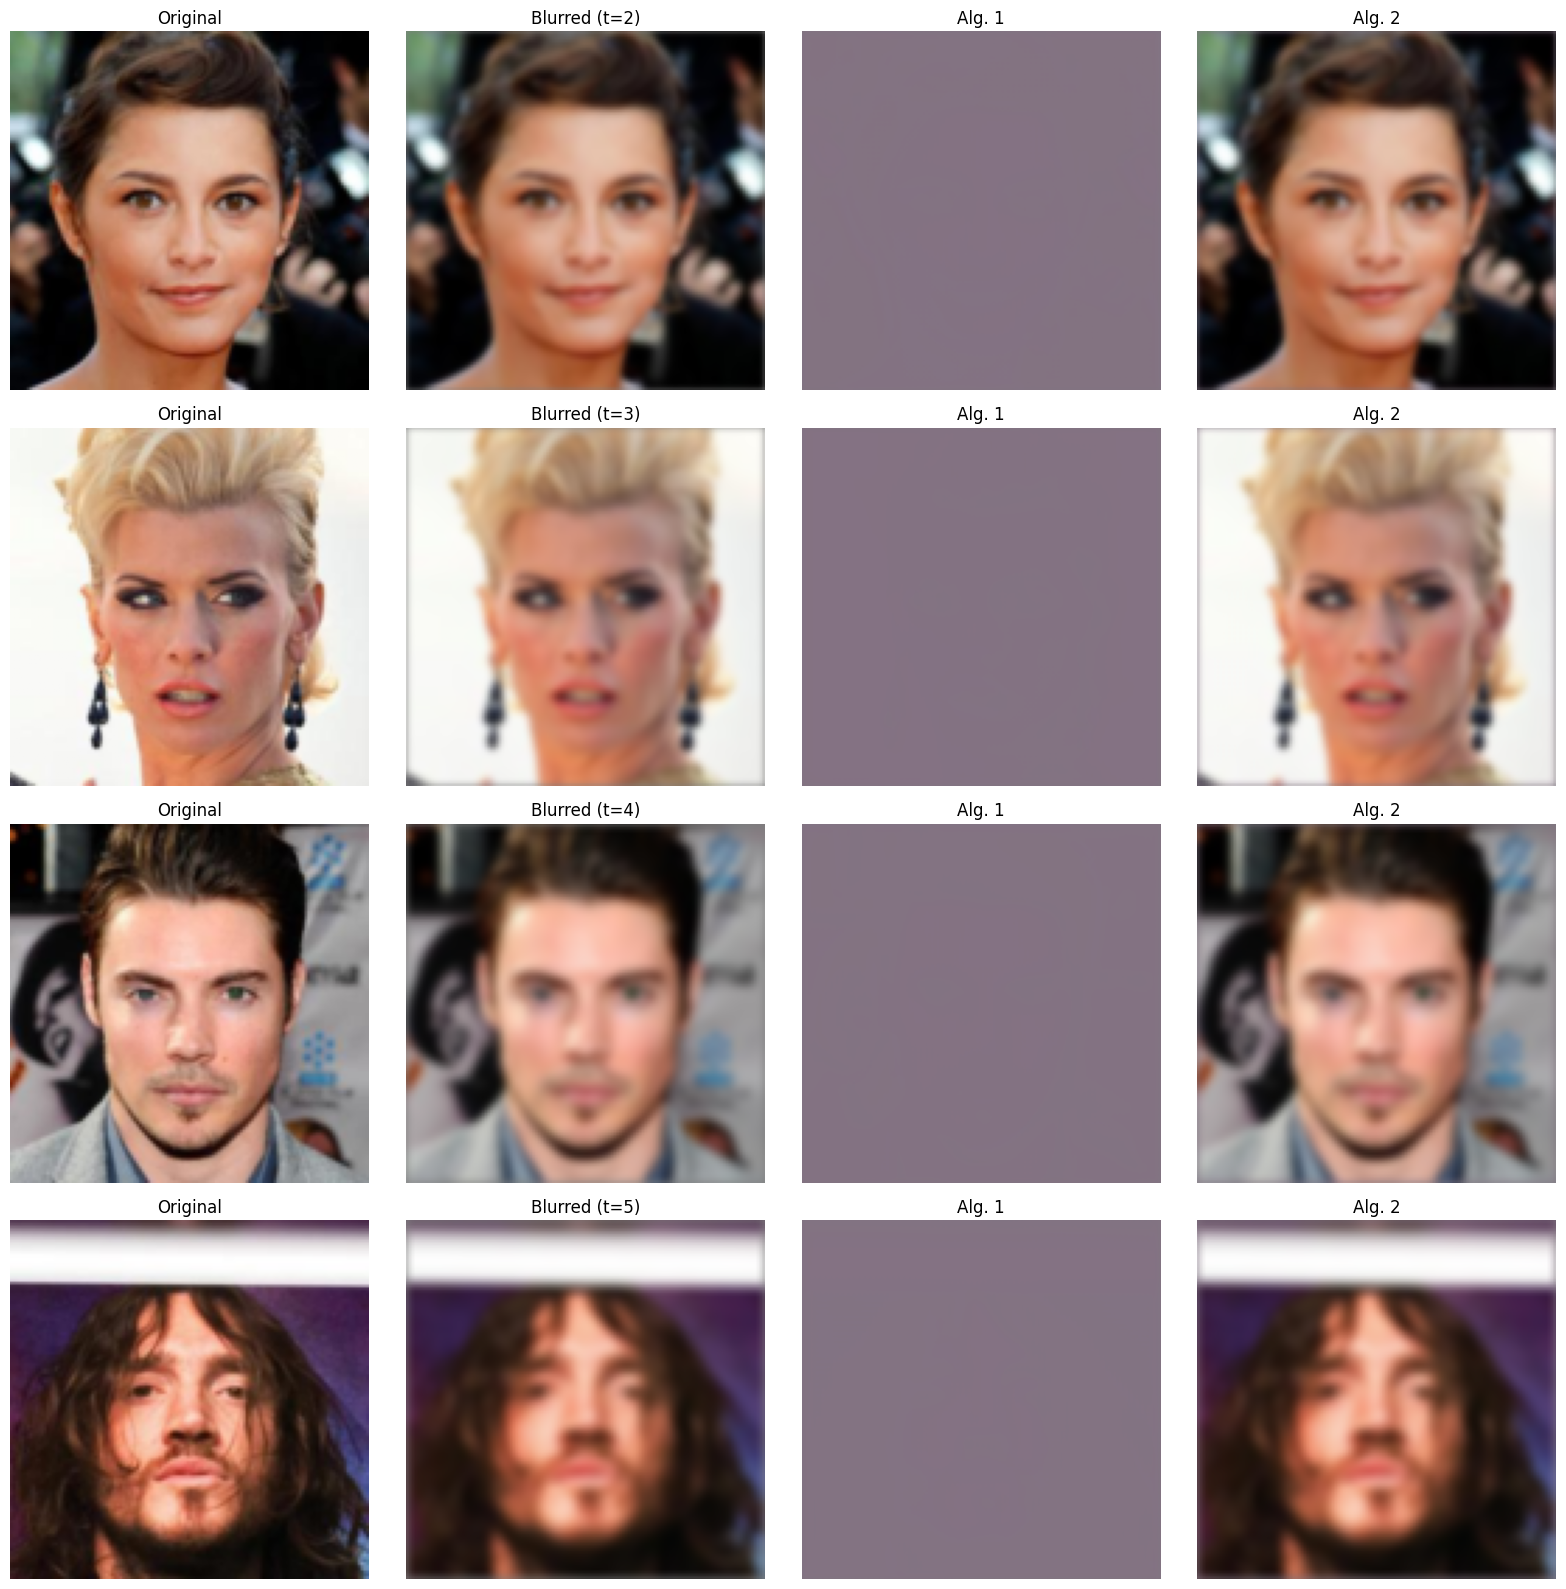

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.5MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


...


=== BASELINES VS COLD DIFFUSION (blur 15×15) ===
Cold Diffusion     → PSNR=28.672, SSIM=0.894, LPIPS=0.1725
Wiener-like Filter  → PSNR=23.176, SSIM=0.666, LPIPS=0.3868
OpenCV Sharpen      → PSNR=28.357, SSIM=0.850, LPIPS=0.1931


Dump FID images:   4%|▎         | 37/1000 [01:59<51:57,  3.24s/it]


Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth


100%|██████████| 91.2M/91.2M [00:00<00:00, 372MB/s]
100%|██████████| 10/10 [01:48<00:00, 10.89s/it]



FID (Cold Diffusion recon vs real): 64.018

Notebook Cold Diffusion Deblurring COMPLETATO ✔


In [4]:
# ================================================================
# NOTEBOOK UNICO — COLD DIFFUSION DEBLURRING (CelebA-HQ 128x128)
# ================================================================

# ------------------------------------------------
# 0. INSTALLAZIONE LIBRERIE EXTRA
# ------------------------------------------------
!pip install pytorch-msssim lpips pytorch-fid --quiet

# ------------------------------------------------
# 1. MOUNT DI GOOGLE DRIVE
# ------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ------------------------------------------------
# 2. IMPORT PRINCIPALI
# ------------------------------------------------
import os
import math
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
from torchvision.utils import save_image
import torchvision

from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from pytorch_msssim import ssim
import lpips
from pytorch_fid.fid_score import calculate_fid_given_paths
import cv2

# ------------------------------------------------
# 3. DISPOSITIVO
# ------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================================================================
# 4. DATASET CELEBA-HQ (256 -> 128)
# ================================================================
root = "/content/drive/MyDrive/Colab Notebooks/celeba_hq_raw/celeba_hq_256"  # <-- TUO PATH

class CelebAHQDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.files = sorted([f for f in os.listdir(root) if f.lower().endswith(".jpg")])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)   # [0,1] -> [-1,1]
])

full_dataset = CelebAHQDataset(root, transform)

# subset (puoi cambiare subset_size se vuoi più/meno immagini)
subset_size = min(8000, len(full_dataset))
dataset = Subset(full_dataset, list(range(subset_size)))

batch_size = 8
dataloader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=True, num_workers=2, pin_memory=True)

def denorm(x):
    """Da [-1,1] a [0,1]"""
    return (x * 0.5 + 0.5).clamp(0, 1)

print("Dataset size (per le metriche):", len(dataset))

# ================================================================
# 5. PARAMETRI COLD DIFFUSION + BLUR GAUSSIANO
# ================================================================
T = 6               # numero di step (0,...,T-1)
sigma_min = 0.4
sigma_max = 2.0
ksize = 7           # kernel 7x7

def get_sigma(t):
    """
    t: tensor di shape [B] (int o float)
    output: sigma per ogni elemento del batch
    """
    return sigma_min + (sigma_max - sigma_min) * (t.float() / (T - 1))

def gaussian_kernel_batch(sigmas, ksize=7):
    """
    Costruisce kernel gaussiani 2D per ogni sigma nel batch.
    sigmas: [B]
    return: [B,1,ksize,ksize]
    """
    B = sigmas.size(0)
    ax = torch.arange(ksize, device=sigmas.device) - (ksize - 1) / 2.0
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")

    xx = xx.expand(B, ksize, ksize)
    yy = yy.expand(B, ksize, ksize)

    sigmas = sigmas.view(B, 1, 1)
    K = torch.exp(-(xx**2 + yy**2) / (2 * sigmas**2))
    K = K / K.sum(dim=(1, 2), keepdim=True)   # normalizza ogni kernel
    return K.view(B, 1, ksize, ksize)

def blur_batch(x, t, ksize=7):
    """
    Applica blur gaussiano per-batch con sigma(t).
    x: [B,C,H,W] in [-1,1]
    t: [B] interi in [0, T-1]
    """
    B, C, H, W = x.shape
    sigmas = get_sigma(t).to(x.device)         # [B]

    K = gaussian_kernel_batch(sigmas, ksize).repeat(1, C, 1, 1)  # [B,C,ksize,ksize]

    # grouped conv: ogni immagine / canale ha il proprio kernel
    xF = x.view(1, B*C, H, W)
    KF = K.view(B*C, 1, ksize, ksize)

    y = F.conv2d(xF, KF, padding=ksize//2, groups=B*C)
    return y.view(B, C, H, W)

# ================================================================
# 6. MODELLO: UNetDeblur (Cold Diffusion)
# ================================================================
class Block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.model(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.block = Block(in_ch, out_ch)

    def forward(self, x):
        x = self.pool(x)
        return self.block(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.block = Block(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # padding per allineare
        dY = x2.size(2) - x1.size(2)
        dX = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [dX // 2, dX - dX // 2,
                       dY // 2, dY - dY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.block(x)

class UNetDeblur(nn.Module):
    def __init__(self, base_ch=28):
        super().__init__()
        # input: 3 canali RGB + 1 canale tempo = 4
        self.inc   = Block(4, base_ch)
        self.down1 = Down(base_ch, base_ch * 2)
        self.down2 = Down(base_ch * 2, base_ch * 4)
        self.bot   = Block(base_ch * 4, base_ch * 4)
        self.up1   = Up(base_ch * 4, base_ch * 2)
        self.up2   = Up(base_ch * 2, base_ch)
        self.outc  = nn.Conv2d(base_ch, 3, 1)

    def forward(self, x_t, t):
        """
        x_t: [B,3,H,W]
        t  : [B] interi in [0,T-1]
        """
        B, _, H, W = x_t.shape
        tmap = (t.float() / (T - 1)).view(B, 1, 1, 1).expand(B, 1, H, W)  # [B,1,H,W]
        x = torch.cat([x_t, tmap], dim=1)  # [B,4,H,W]

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        xb = self.bot(x3)
        x  = self.up1(xb, x2)
        x  = self.up2(x, x1)
        out = self.outc(x)
        return out

# ================================================================
# 7. TRAINING (OPZIONALE)
# ================================================================
MODEL_PATH = "/content/drive/MyDrive/cold_diffusion_deblur_model.pth"
TRAIN_MODEL = False   # <-- metti True se vuoi allenare da zero

def train_model(
    model,
    dataloader,
    num_epochs=4,
    lr=2e-4,
    save_path=MODEL_PATH
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    global_step = 0
    model.train()
    for epoch in range(num_epochs):
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for x0 in pbar:
            x0 = x0.to(device)  # [B,3,H,W]

            B = x0.size(0)
            # campiono t in [1, T-1] (evito t=0 per training deblurring)
            t = torch.randint(1, T, (B,), device=device)
            x_t = blur_batch(x0, t)  # forward deterministico

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                x0_hat = model(x_t, t)
                loss = (x0_hat - x0).abs().mean()   # L1

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            global_step += 1
            pbar.set_postfix({"loss": loss.item()})

        # salvataggio ogni epoca
        torch.save(model.state_dict(), save_path)
        print(f"Epoch {epoch+1} terminata. Modello salvato in: {save_path}")

    print("Training completato.")
    return model

model = UNetDeblur().to(device)

if TRAIN_MODEL:
    model = train_model(model, dataloader, num_epochs=4, save_path=MODEL_PATH)
else:
    # carico pesi se esistono
    if os.path.exists(MODEL_PATH):
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        print("Modello caricato da:", MODEL_PATH)
    else:
        print("ATTENZIONE: MODEL_PATH non esiste, devi prima allenare (TRAIN_MODEL=True).")

model.eval()

# ================================================================
# 8. ALGORITMI DI RICOSTRUZIONE (COLD DIFFUSION)
# ================================================================
@torch.no_grad()
def reconstruct_algorithm1(x_t, t):
    """
    Algoritmo 1: singolo passo (naive)
    """
    return model(x_t, t)

@torch.no_grad()
def cold_step(x_t, t):
    """
    Algoritmo 2: passo di correzione residua
    x_{t-1} = x_t - D(x0_hat, t) + D(x0_hat, t-1)
    """
    x0_hat = model(x_t, t)                   # stima x0
    D_t = blur_batch(x0_hat, t)              # D(x0_hat, t)
    t_minus = torch.clamp(t - 1, min=0)
    D_t_minus = blur_batch(x0_hat, t_minus)  # D(x0_hat, t-1)
    return x_t - D_t + D_t_minus

@torch.no_grad()
def reconstruct_algorithm2(x_T):
    """
    Algoritmo 2: inversione iterativa dalla immagine fortemente blurred x_T.
    x_T corrisponde a t = T-1.
    """
    x = x_T
    B = x.size(0)
    # scendiamo da T-1 a 1
    for tt in reversed(range(1, T)):
        t = torch.full((B,), tt, device=device, dtype=torch.long)
        x = cold_step(x, t)
    return x

# ================================================================
# 9. VISUALIZZAZIONE RAPIDA (OPZIONALE)
# ================================================================
@torch.no_grad()
def show_comparison(n=4):
    model.eval()
    x0 = next(iter(dataloader))[:n].to(device)      # immagini pulite
    t  = torch.randint(1, T, (n,), device=device)   # livelli di blur diversi

    x_t  = blur_batch(x0, t)
    rec1 = reconstruct_algorithm1(x_t, t)
    rec2 = reconstruct_algorithm2(x_t)

    x0_d = denorm(x0).cpu()
    x_t_d = denorm(x_t).cpu()
    r1_d = denorm(rec1).cpu()
    r2_d = denorm(rec2).cpu()

    fig, ax = plt.subplots(n, 4, figsize=(16, 4*n))
    for i in range(n):
        ax[i,0].imshow(x0_d[i].permute(1,2,0)); ax[i,0].set_title("Original"); ax[i,0].axis("off")
        ax[i,1].imshow(x_t_d[i].permute(1,2,0)); ax[i,1].set_title(f"Blurred (t={t[i].item()})"); ax[i,1].axis("off")
        ax[i,2].imshow(r1_d[i].permute(1,2,0)); ax[i,2].set_title("Alg. 1"); ax[i,2].axis("off")
        ax[i,3].imshow(r2_d[i].permute(1,2,0)); ax[i,3].set_title("Alg. 2"); ax[i,3].axis("off")
    plt.tight_layout()
    plt.show()

# ESEMPIO (puoi commentarlo se non ti serve subito)
show_comparison(4)

# ================================================================
# 10. METRICHE: PSNR, SSIM, LPIPS (Cold Diffusion)
# ================================================================
def PSNR(x, y):
    """
    x, y in [0,1], tensori [3,H,W]
    """
    mse = torch.mean((x - y)**2).item()
    if mse == 0:
        return 99.0
    return 20 * math.log10(1.0 / math.sqrt(mse))

# LPIPS (perceptual distance)
lpips_loss = lpips.LPIPS(net='vgg').to(device)

@torch.no_grad()
def evaluate_cold(max_images=200):
    """
    Valuta Cold Diffusion su max_images immagini.
    Restituisce PSNR medio, SSIM medio, LPIPS medio.
    """
    model.eval()
    psnr_list = []
    ssim_list = []
    lp_list   = []

    count = 0
    for x0 in tqdm(dataloader, desc="ColdDiff metrics"):
        x0 = x0.to(device)
        B  = x0.size(0)

        t = torch.randint(1, T, (B,), device=device)
        x_t  = blur_batch(x0, t)
        xrec = reconstruct_algorithm2(x_t)   # usiamo Alg.2 (migliore)

        x0_d = denorm(x0)
        xr_d = denorm(xrec)

        for i in range(B):
            psnr_list.append(PSNR(xr_d[i], x0_d[i]))
            ssim_val = ssim(
                xr_d[i].unsqueeze(0),
                x0_d[i].unsqueeze(0),
                data_range=1.0
            ).item()
            ssim_list.append(ssim_val)

        # LPIPS richiede [-1,1]
        lp_val = lpips_loss((xrec), (x0)).mean().item()
        lp_list.append(lp_val)

        count += B
        if count >= max_images:
            break

    psnr_mean = sum(psnr_list) / len(psnr_list)
    ssim_mean = sum(ssim_list) / len(ssim_list)
    lp_mean   = sum(lp_list)   / len(lp_list)
    return psnr_mean, ssim_mean, lp_mean

psnr_cd, ssim_cd, lpips_cd = evaluate_cold(max_images=200)
print(f"\nCold Diffusion → PSNR={psnr_cd:.3f}, SSIM={ssim_cd:.3f}, LPIPS={lpips_cd:.4f}")

# ================================================================
# 11. BASELINES CLASSICHE: WIENER & SHARPEN
# ================================================================
def apply_variable_blur(x, ksize=15, sigma=2.0):
    """
    Applica blur gaussiano "classico" (OpenCV-style) a x in [0,1].
    x: [B,3,H,W]
    """
    B, C, H, W = x.shape
    out = []
    for i in range(B):
        img = x[i].permute(1,2,0).cpu().numpy()
        img = (img * 255).astype(np.uint8)
        blur = cv2.GaussianBlur(img, (ksize, ksize), sigma)
        blur = blur.astype(np.float32) / 255.0
        out.append(torch.tensor(blur).permute(2,0,1).unsqueeze(0))
    return torch.cat(out, dim=0)

def wiener_deblur(x):
    """
    Semplice filtro "deblur" di tipo media (non è un vero Wiener,
    ma un baseline denoising / smoothing).
    x: [3,H,W] in [0,1]
    """
    img = x.permute(1,2,0).cpu().numpy()
    img = (img * 255).astype(np.uint8)
    ksize = 9
    kernel = np.ones((ksize, ksize), np.float32) / (ksize * ksize)
    out = cv2.filter2D(img, -1, kernel)
    out = out.astype(np.float32) / 255.0
    return torch.tensor(out).permute(2,0,1).float()

def sharpen_deblur(x):
    """
    Filtro sharpen (edge-enhancing).
    x: [3,H,W] in [0,1]
    """
    img = x.permute(1,2,0).cpu().numpy()
    img = (img * 255).astype(np.uint8)
    blur = cv2.GaussianBlur(img, (0,0), 3)
    sharp = cv2.addWeighted(img, 1.5, blur, -0.5, 0)
    sharp = sharp.astype(np.float32) / 255.0
    return torch.tensor(sharp).permute(2,0,1).float()

@torch.no_grad()
def eval_classical(method_fn, max_images=200):
    """
    Valuta metodo classico (wiener/sharpen) su immagini blurate.
    """
    psnr_list = []
    ssim_list = []
    lp_list   = []

    count = 0
    for x0 in tqdm(dataloader, desc=f"{method_fn.__name__}"):
        x0 = x0.to(device)
        x0_d = denorm(x0)  # [0,1]

        x_blur = apply_variable_blur(x0_d, ksize=15, sigma=2.0).to(device)  # baseline blur

        rec_list = []
        for i in range(x0_d.size(0)):
            r = method_fn(x_blur[i].cpu())
            rec_list.append(r.unsqueeze(0))
        xrec = torch.cat(rec_list, dim=0).to(device).clamp(0,1)

        for i in range(xrec.size(0)):
            psnr_list.append(PSNR(xrec[i], x0_d[i]))
            ssim_val = ssim(
                xrec[i].unsqueeze(0),
                x0_d[i].unsqueeze(0),
                data_range=1.0
            ).item()
            ssim_list.append(ssim_val)

        lp_val = lpips_loss((xrec*2-1), (x0_d*2-1)).mean().item()
        lp_list.append(lp_val)

        count += x0.size(0)
        if count >= max_images:
            break

    psnr_mean = sum(psnr_list) / len(psnr_list)
    ssim_mean = sum(ssim_list) / len(ssim_list)
    lp_mean   = sum(lp_list)   / len(lp_list)
    return psnr_mean, ssim_mean, lp_mean

psnr_w, ssim_w, lpips_w = eval_classical(wiener_deblur, max_images=200)
psnr_s, ssim_s, lpips_s = eval_classical(sharpen_deblur, max_images=200)

print("\n=== BASELINES VS COLD DIFFUSION (blur 15×15) ===")
print(f"Cold Diffusion     → PSNR={psnr_cd:.3f}, SSIM={ssim_cd:.3f}, LPIPS={lpips_cd:.4f}")
print(f"Wiener-like Filter  → PSNR={psnr_w:.3f}, SSIM={ssim_w:.3f}, LPIPS={lpips_w:.4f}")
print(f"OpenCV Sharpen      → PSNR={psnr_s:.3f}, SSIM={ssim_s:.3f}, LPIPS={lpips_s:.4f}")

# ================================================================
# 12. FID (Fréchet Inception Distance) — COLD DIFFUSION
# ================================================================
real_dir  = "/content/fid_real"
recon_dir = "/content/fid_recon"
os.makedirs(real_dir, exist_ok=True)
os.makedirs(recon_dir, exist_ok=True)
to_pil = torchvision.transforms.ToPILImage()

@torch.no_grad()
def dump_for_fid(max_images=300):
    model.eval()
    count = 0
    for x0 in tqdm(dataloader, desc="Dump FID images"):
        x0 = x0.to(device)
        B  = x0.size(0)
        t = torch.randint(1, T, (B,), device=device)
        x_t  = blur_batch(x0, t)
        xrec = reconstruct_algorithm2(x_t)

        x0_v   = denorm(x0).cpu()
        xrec_v = denorm(xrec).cpu()

        for i in range(B):
            to_pil(x0_v[i]).save(f"{real_dir}/{count+i}.png")
            to_pil(xrec_v[i]).save(f"{recon_dir}/{count+i}.png")

        count += B
        if count >= max_images:
            break

dump_for_fid(300)

fid_value = calculate_fid_given_paths(
    [real_dir, recon_dir],
    batch_size=32, device=device, dims=2048
)

print(f"\nFID (Cold Diffusion recon vs real): {fid_value:.3f}")
print("\nNotebook Cold Diffusion Deblurring COMPLETATO ✔")
